In [26]:
#!/usr/bin/env python
# coding: utf-8

"""
Generate figures for ETC storm-type paper using precomputed CSVs in ../processed.

This script:
  - Loads precomputed RR/RD summaries (no bootstrap here)
  - Remakes the forest-plot figures and diagnostic plots
  - Loads the event-level storm CSV to remake feature distribution histograms
  - Saves everything into ../figures
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Paths + save helper
# ============================================================

PROCESSED_DIR = "../processed"
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, filename, dpi=300):
    fig.savefig(os.path.join(FIG_DIR, filename), dpi=dpi, bbox_inches="tight")
    plt.close(fig)


# ============================================================
# Load precomputed (no recomputation) tables
# ============================================================

# These come from your analysis notebook "save outputs" block
rr_df_all = pd.read_csv(os.path.join(PROCESSED_DIR, "rr_df_all_seasons.csv"))
rr_df_seasons = pd.read_csv(os.path.join(PROCESSED_DIR, "rr_df_by_season.csv"))

season_counts = pd.read_csv(
    os.path.join(PROCESSED_DIR, "storm_counts_by_season_and_type.csv"),
    index_col=0
)
season_frac = pd.read_csv(
    os.path.join(PROCESSED_DIR, "storm_fraction_by_season_and_type.csv"),
    index_col=0
)
month_counts = pd.read_csv(
    os.path.join(PROCESSED_DIR, "storm_counts_by_month_and_type.csv"),
    index_col=0
)
month_frac = pd.read_csv(
    os.path.join(PROCESSED_DIR, "storm_fraction_by_month_and_type.csv"),
    index_col=0
)

# Event-level storms file (you showed this exact filename earlier)
df = pd.read_csv(os.path.join(PROCESSED_DIR, "cfsr_storms_labeled_k2.csv"))

# Ensure storm_type exists (in case it's not saved in the CSV)
TYPE1 = "Type 1 (Earlier-entry storms)"
TYPE2 = "Type 2 (Later-entry storms)"
if "storm_type" not in df.columns:
    if "k2_cluster" not in df.columns:
        raise ValueError("Expected 'storm_type' or 'k2_cluster' in event-level CSV.")
    df["storm_type"] = df["k2_cluster"].map({0: TYPE2, 1: TYPE1})


# ============================================================
# Plot metadata (must match analysis)
# ============================================================

LAKE_LABELS = {"sup": "Superior", "mi": "Michigan", "huron": "Huron", "erie": "Erie", "ont": "Ontario"}
LAKE_ORDER  = ["sup", "mi", "huron", "erie", "ont"]
SEASON_TITLES = {"DJF": "Winter (DJF)", "MAM": "Spring (MAM)", "JJA": "Summer (JJA)", "SON": "Fall (SON)"}


# ============================================================
# Forest plot helpers
# ============================================================

def prep_for_plot(rr_df: pd.DataFrame, impact: str, season: str | None = None) -> pd.DataFrame:
    d = rr_df[rr_df["impact"] == impact].copy()
    if season is not None:
        d = d[d["season"] == season].copy()

    d["lake"] = d["lake"].astype(str).str.lower()
    d = d[d["lake"].isin(LAKE_ORDER)]
    d["lake_label"] = d["lake"].map(LAKE_LABELS)

    d["lake"] = pd.Categorical(d["lake"], categories=LAKE_ORDER, ordered=True)
    return d.sort_values("lake").reset_index(drop=True)

def forest(ax, d: pd.DataFrame, metric: str, title: str, xlabel: str, ref_value: float | None = None):
    if d.empty:
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, alpha=0.7)
        ax.set_yticks([])
        if ref_value is not None:
            ax.axvline(ref_value, linestyle="--", linewidth=1)
        ax.grid(True, axis="x", alpha=0.3)
        return

    y = np.arange(len(d))
    med = d[f"{metric}_median"].to_numpy()
    low = d[f"{metric}_low"].to_numpy()
    high = d[f"{metric}_high"].to_numpy()
    xerr = np.vstack([med - low, high - med])

    ax.errorbar(med, y, xerr=xerr, fmt="o", capsize=3)
    if ref_value is not None:
        ax.axvline(ref_value, linestyle="--", linewidth=1)

    ax.set_yticks(y)
    ax.set_yticklabels(d["lake_label"])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True, axis="x", alpha=0.3)



In [27]:
# ============================================================
# Figures: RR/RD forest plots
# ============================================================

def plot_all_seasons_2x2(rr_df_all: pd.DataFrame):
    d_evap   = prep_for_plot(rr_df_all, "evap")
    d_precip = prep_for_plot(rr_df_all, "precip")

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)

    forest(axes[0, 0], d_evap,   "rr", "Evaporation extremes: Risk ratio",        "P(Extreme | Later entry) / P(Extreme | Earlier entry)", 1.0)
    forest(axes[0, 1], d_evap,   "rd", "Evaporation extremes: Risk difference",   "P(Extreme | Later entry) - P(Extreme | Earlier entry)", 0.0)
    forest(axes[1, 0], d_precip, "rr", "Precipitation extremes: Risk ratio",      "P(Extreme | Later entry) / P(Extreme | Earlier entry)", 1.0)
    forest(axes[1, 1], d_precip, "rd", "Precipitation extremes: Risk difference", "P(Extreme | Later entry) - P(Extreme | Earlier entry)", 0.0)

    panel_labels = ["(a)", "(b)", "(c)", "(d)"]
    for ax, label in zip(axes.flatten(), panel_labels):
        ax.text(
            -0.08, 1.10, label,
            transform=ax.transAxes,
            fontsize=11,
            fontweight="bold",
            va="top",
            ha="left",
            clip_on=False,
        )

    print(d_evap)

    for ax in axes[:, 1]:
        ax.tick_params(labelleft=True)

    fig.tight_layout(rect=[0.03, 0.03, 1, 0.97])
    return fig, axes


def plot_takehome_son_evap_jja_precip(rr_df_seasons: pd.DataFrame):
    d_evap_son   = prep_for_plot(rr_df_seasons, "evap",   season="SON")
    d_precip_jja = prep_for_plot(rr_df_seasons, "precip", season="JJA")

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)

    forest(axes[0, 0], d_evap_son,   "rr", "Fall (SON) evaporation extremes: RR",     "P(Extreme | Later entry) / P(Extreme | Earlier entry)", 1.0)
    forest(axes[0, 1], d_evap_son,   "rd", "Fall (SON) evaporation extremes: RD",     "P(Extreme | Later entry) - P(Extreme | Earlier entry)", 0.0)
    forest(axes[1, 0], d_precip_jja, "rr", "Summer (JJA) precipitation extremes: RR", "P(Extreme | Later entry) / P(Extreme | Earlier entry)", 1.0)
    forest(axes[1, 1], d_precip_jja, "rd", "Summer (JJA) precipitation extremes: RD", "P(Extreme | Later entry) - P(Extreme | Earlier entry)", 0.0)

    panel_labels = ["(a)", "(b)", "(c)", "(d)"]
    for ax, label in zip(axes.flatten(), panel_labels):
        ax.text(
            -0.08, 1.10, label,
            transform=ax.transAxes,
            fontsize=11,
            fontweight="bold",
            va="top",
            ha="left",
            clip_on=False,
        )

    for ax in axes[:, 1]:
        ax.tick_params(labelleft=True)

    fig.tight_layout(rect=[0.03, 0.03, 1, 0.97])
    return fig, axes

In [28]:

# ============================================================
# Figures: diagnostics
# ============================================================

def plot_monthly_distribution(month_frac: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(9, 4))
    month_frac.plot(kind="bar", ax=ax)
    ax.set_ylabel("Fraction of storms")
    ax.set_xlabel("Month")
    ax.set_title("Monthly distribution of storm types")
    ax.legend(title="Storm type")
    fig.tight_layout()
    return fig, ax



In [29]:
# ============================================================
# Figures: feature distributions by storm type 
# ============================================================

def plot_feature_distributions(df: pd.DataFrame):
    features = [
        "maturity_glr0_minus_genesis_ratio",
        "fraction_of_time_in_GLR",
        "max_radius",
        "min_p_cent",
        "max_uv",
        "max_p_grad",
    ]

    VAR_LABELS = {
        "maturity_glr0_minus_genesis_ratio": "Maturity proxy at GLR entry",
        "fraction_of_time_in_GLR": "Fraction of storm lifetime in GLR",
        "max_radius": "Max. storm radius (km)",
        "min_p_cent": "Min. central pressure (hPa)",
        "max_uv": "Max. storm speed (m s$^{-1}$)",
        "max_p_grad": "Max. pressure gradient (hPa 100 km$^{-1}$)",
    }

    storm_types = [TYPE1, TYPE2]

    colors = {
        TYPE1: "tab:blue",
        TYPE2: "tab:orange",
    }

    # Panel labels
    panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

    # Basic validation (fail loudly)
    missing = [c for c in (features + ["storm_type"]) if c not in df.columns]
    if missing:
        raise ValueError(f"Event-level df is missing columns needed for feature plot: {missing}")

    fig, axes = plt.subplots(2, 3, figsize=(11, 6))
    axes = axes.flatten()

    for i, (ax, var) in enumerate(zip(axes, features)):
        data_all = df[var].dropna()
        if data_all.empty:
            ax.set_title(VAR_LABELS.get(var, var), fontsize=10)
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, alpha=0.7)
            ax.set_yticks([])
            continue

        bins = np.histogram_bin_edges(data_all, bins=30)

        hists = {}
        max_count = 0
        for stype in storm_types:
            vals = df.loc[df["storm_type"] == stype, var].dropna()
            counts, _ = np.histogram(vals, bins=bins)
            hists[stype] = counts
            max_count = max(max_count, counts.max() if len(counts) else 0)

        # Avoid division by zero
        max_count = max(max_count, 1)

        for stype in storm_types:
            y = hists[stype] / max_count
            ax.step(
                bins[:-1], y, where="post",
                color=colors[stype], linewidth=1.5,
                label=stype if i == 0 else None
            )
            ax.fill_between(
                bins[:-1], y, step="post",
                color=colors[stype], alpha=0.35
            )

        ax.set_title(VAR_LABELS.get(var, var), fontsize=10)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Relative frequency")

        # ---- Panel label ----
        ax.text(
            -0.08, 1.10, panel_labels[i],
            transform=ax.transAxes,
            fontsize=11,
            fontweight="bold",
            va="top",
            ha="left",
            clip_on=False,
        )

        if i==0:
            ax.set_xlim(0,0.95)
            ax.legend(frameon=False, fontsize=9)
        elif i==1:
            ax.set_xlim(0,0.95)
        elif i==2:
            ax.set_xlim(300,3000)
        elif i==3:
            ax.set_xlim(960,1020)
        elif i==4:
            ax.set_xlim(30, 180)
        elif i==5:
            ax.set_xlim(8, 45)
        else:
            print("How did you get here?")
            
    fig.tight_layout()
    return fig, axes

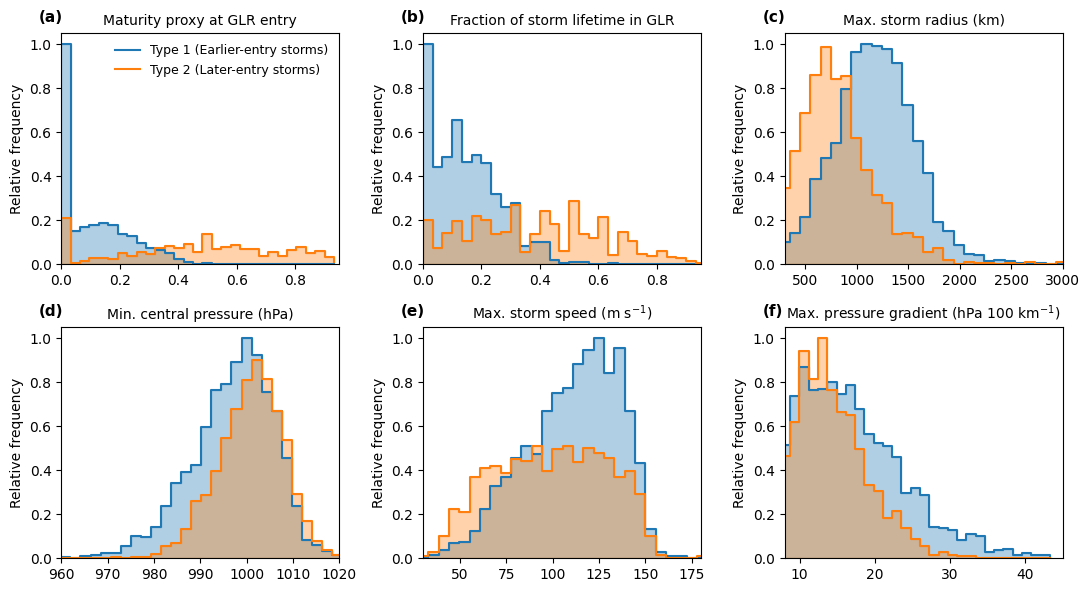

    lake impact    rr_low  rr_median   rr_high    rd_low  rd_median   rd_high  \
0    sup   evap  0.946726   1.282261  1.739673 -0.002512   0.012637  0.028488   
1     mi   evap  0.979444   1.314327  1.772159 -0.001068   0.013709  0.029055   
2  huron   evap  0.966450   1.318574  1.764124 -0.001619   0.014053  0.029079   
3   erie   evap  0.780893   1.062460  1.414971 -0.012124   0.002975  0.018075   
4    ont   evap  1.117062   1.517160  2.063614  0.005394   0.021210  0.036777   

   n_rr_valid  n_rd_valid lake_label  
0        2000        2000   Superior  
1        2000        2000   Michigan  
2        2000        2000      Huron  
3        2000        2000       Erie  
4        2000        2000    Ontario  


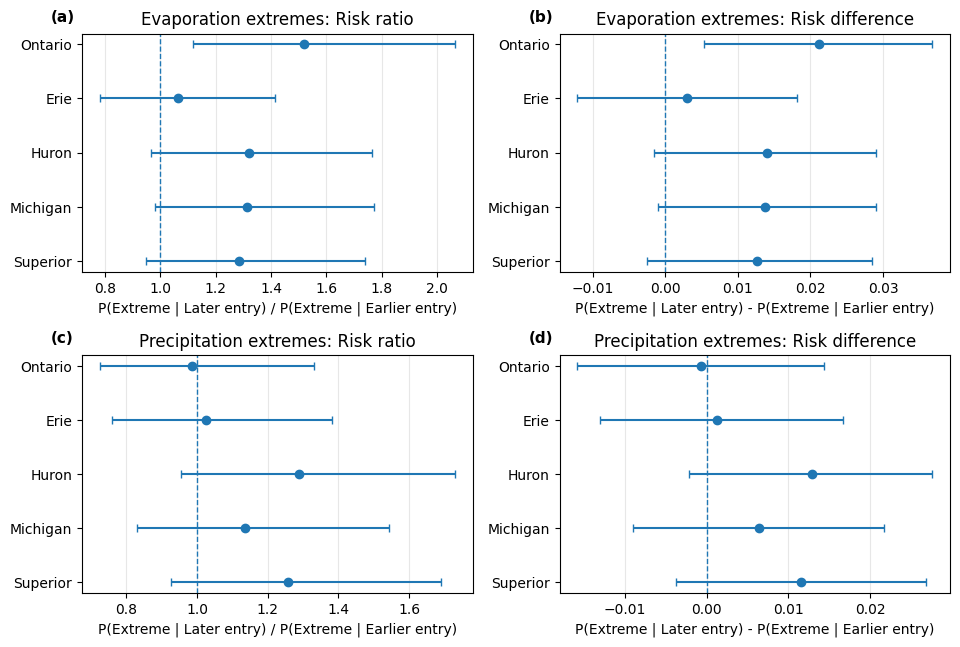

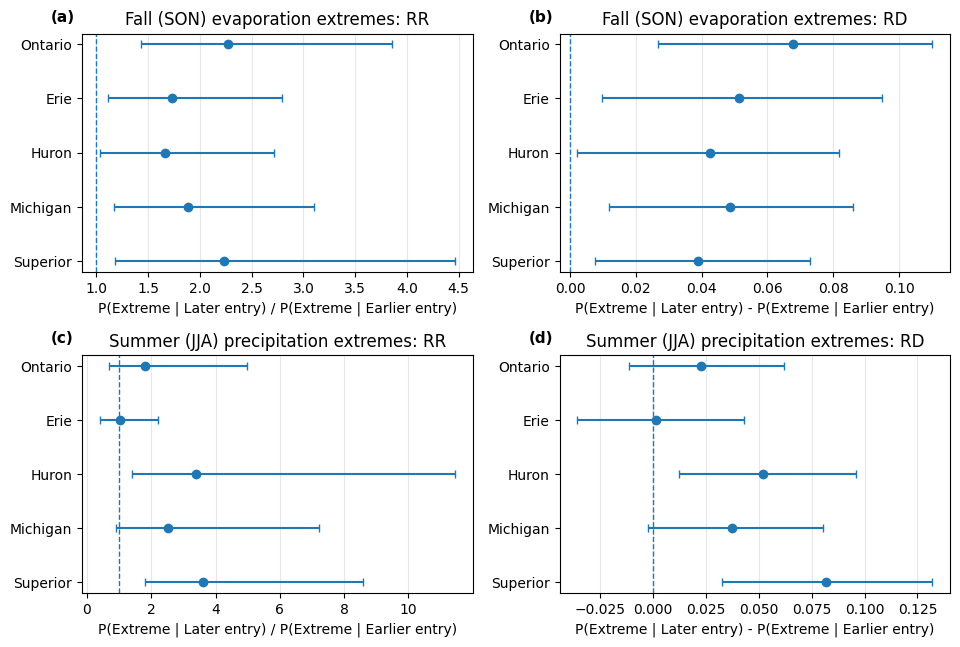

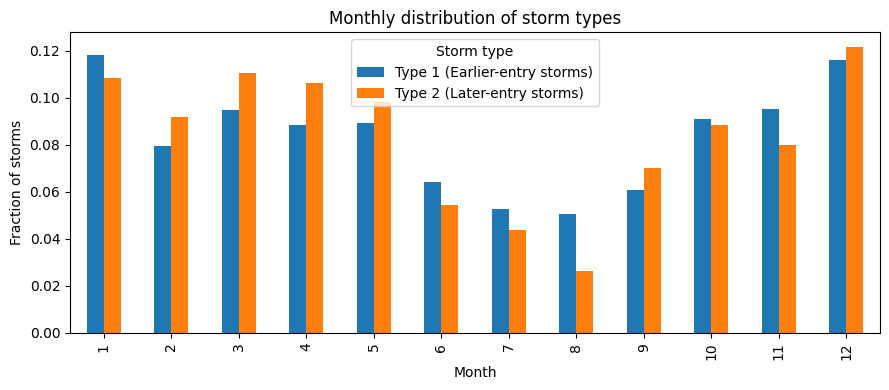

Saved figures to: ../figures


In [30]:

# ============================================================
# Run: save all figures
# ============================================================

# Feature distributions
fig, _ = plot_feature_distributions(df)
plt.show()
save_fig(fig, "fig_feature_distributions_by_type.png")

# RR/RD forest plots
fig, _ = plot_all_seasons_2x2(rr_df_all)
plt.show()
save_fig(fig, "fig_all_seasons_rr_rd_2x2.png")

fig, _ = plot_takehome_son_evap_jja_precip(rr_df_seasons)
plt.show()
save_fig(fig, "fig_takehome_son_evap_jja_precip_2x2.png")

# Monthly distribution
fig, _ = plot_monthly_distribution(month_frac)
plt.show()
save_fig(fig, "fig_monthly_distribution_storm_types.png")



print(f"Saved figures to: {FIG_DIR}")
